<a href="https://colab.research.google.com/github/azeltkr/breast-cancer-cbis-ddsm/blob/main/CM3070_prototype_cbis_ddsm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CM3070 Feature Prototype (Kaggle route)
## Deep Learning for Breast Cancer Detection (CBIS-DDSM)

This notebook loads CBIS-DDSM from Kaggle (JPEG images + CSV labels), bypassing TensorFlow Datasets. It implements **Steps 1 to 3** of the Chollet pipeline (framing, data preparation, baseline CNN) plus a short **VGG16 transfer-learning** taste, and evaluates with **AUC-ROC, sensitivity, specificity, and a confusion matrix**.



In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Download the dataset
!pip install -q kaggle
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset
!unzip -q -o cbis-ddsm-breast-cancer-image-dataset.zip -d /content/cbis
print('Done. Top-level contents:')
!ls /content/cbis

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:48<00:00, 110MB/s]

Done. Top-level contents:
csv  jpeg


## 1. Inspect the CSV label files

This dataset ships with calc and mass case description CSVs. We inspect them so the label handling is transparent.

In [14]:
import pandas as pd, glob

csvs = glob.glob('/content/cbis/csv/*.csv')
print('CSV files found:')
for c in csvs:
    print(' ', c)

# Peek at one to see columns
sample = pd.read_csv(csvs[0])
print('\nColumns:', list(sample.columns))
sample.head()

CSV files found:
  /content/cbis/csv/dicom_info.csv
  /content/cbis/csv/mass_case_description_test_set.csv
  /content/cbis/csv/mass_case_description_train_set.csv
  /content/cbis/csv/meta.csv
  /content/cbis/csv/calc_case_description_test_set.csv
  /content/cbis/csv/calc_case_description_train_set.csv

Columns: ['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue', 'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyIns

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [15]:
# Look at the directory layout for the images (jpeg folder).
!ls /content/cbis | head
print('---')
!ls /content/cbis/jpeg 2>/dev/null | head || echo 'no jpeg/ folder; checking alternatives'
print('--- dicom_info or meta ---')
!ls /content/cbis/csv

csv
jpeg
---
1.3.6.1.4.1.9590.100.1.2.100018879311824535125115145152454291132
1.3.6.1.4.1.9590.100.1.2.100131208110604806117271735422083351547
1.3.6.1.4.1.9590.100.1.2.100522099512256189513864912954167862869
1.3.6.1.4.1.9590.100.1.2.100522676511025180541602449080267145647
1.3.6.1.4.1.9590.100.1.2.10055294210766234140934516480682841962
1.3.6.1.4.1.9590.100.1.2.100579676611077714807988832023693299884
1.3.6.1.4.1.9590.100.1.2.100631678311747240317898717702514834166
1.3.6.1.4.1.9590.100.1.2.100632214012866120117337678502539182046
1.3.6.1.4.1.9590.100.1.2.100682860911308271813943300011840547108
1.3.6.1.4.1.9590.100.1.2.100764250811134786606184452222065316702
--- dicom_info or meta ---
calc_case_description_test_set.csv   mass_case_description_test_set.csv
calc_case_description_train_set.csv  mass_case_description_train_set.csv
dicom_info.csv			     meta.csv


## 2. Build a labelled dataframe (image path -> binary label)

We combine the calc and mass training/test description CSVs, map `pathology` to a binary label (`MALIGNANT` -> 1, otherwise 0), and resolve the image paths. The dataset stores images under `jpeg/<hash>/` and maps them via `dicom_info.csv`.


In [8]:
import pandas as pd, os, glob

csv_dir = '/content/cbis/csv'

# 1. Load all four description CSVs and attach the binary label
frames = []
for f in ['calc_case_description_train_set.csv', 'calc_case_description_test_set.csv',
          'mass_case_description_train_set.csv', 'mass_case_description_test_set.csv']:
    p = os.path.join(csv_dir, f)
    if os.path.exists(p):
        df = pd.read_csv(p)
        frames.append(df)
desc = pd.concat(frames, ignore_index=True)
desc['label'] = (desc['pathology'].str.upper() == 'MALIGNANT').astype(int)
print("Description rows:", len(desc))
print("Label counts:\n", desc['label'].value_counts())

# 2. Use dicom_info to map full-mammogram images, keyed by the DDSM-style name
di = pd.read_csv(csv_dir + '/dicom_info.csv')
full = di[di['SeriesDescription'] == 'full mammogram images'].copy()

# Resolve the real jpg path
img_root = '/content/cbis'
full['real_path'] = full['image_path'].str.replace('CBIS-DDSM', img_root, regex=False)

# The PatientID in dicom_info (e.g. Mass-Training_P_01265_RIGHT_MLO) encodes
# patient + side + view. Build the same key from the description CSV and join on it.
def make_key(row):
    # e.g. Mass-Training_P_01265_RIGHT_MLO  -> P_01265_RIGHT_MLO
    pid = str(row['patient_id'])
    side = str(row['left or right breast']).upper().strip()
    view = str(row['image view']).upper().strip()
    return f"{pid}_{side}_{view}"

desc['join_key'] = desc.apply(make_key, axis=1)

# Extract the same key from dicom_info PatientID by stripping the prefix and any trailing _n
import re
def extract_key(pid):
    m = re.search(r'(P_\d+_[A-Z]+_[A-Z]+)', str(pid))
    return m.group(1) if m else None
full['join_key'] = full['PatientID'].apply(extract_key)

# 3. Join: each full image gets the label of its matching description row
merged = full.merge(desc[['join_key', 'label']].drop_duplicates('join_key'),
                    on='join_key', how='inner')
merged = merged[merged['real_path'].apply(os.path.exists)]

# pull the patient ID out of the join key (P_00016_LEFT_CC -> P_00016)
merged['patient'] = merged['join_key'].str.extract(r'(P_\d+)')

pairs = list(zip(merged['real_path'], merged['label'], merged['patient']))
print("\nTotal (path, label, patient) triples:", len(pairs))
print("Unique patients:", merged['patient'].nunique())

Description rows: 3568
Label counts:
 label
0    2111
1    1457
Name: count, dtype: int64

Total (path, label, patient) triples: 2857
Unique patients: 1460


> If the path above resolves (`Exists: True`), continue. The next cell joins labels to image paths via the patient/image identifiers and assembles the final training table.

The description CSVs and the image files are linked through `dicom_info.csv`.
We filter to `full mammogram images` rather than the cropped ROI patches,
because the research question concerns whole-image screening: a real screening
model receives an entire mammogram, not a pre-localised region. This is also
the main structural difference from Shen et al. (2019), who trained a patch
classifier on the ROI annotations before converting it to a whole-image model.

## 3. Build tf.data pipelines (resize, normalise, augment, class-weight)

In [9]:
import pandas as pd
csv_dir = '/content/cbis/csv'

desc_sample = pd.read_csv(csv_dir + '/mass_case_description_train_set.csv')
di = pd.read_csv(csv_dir + '/dicom_info.csv')

print("=== DESCRIPTION CSV ===")
print("Columns:", list(desc_sample.columns))
print("patient_id examples:", desc_sample['patient_id'].head(5).tolist() if 'patient_id' in desc_sample.columns else 'NO patient_id COLUMN')

print("\n=== DICOM_INFO ===")
print("Columns:", list(di.columns))
for col in ['PatientID', 'patient_id', 'image_path', 'SeriesDescription']:
    if col in di.columns:
        print(f"{col} examples:", di[col].head(5).tolist())

=== DESCRIPTION CSV ===
Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
patient_id examples: ['P_00001', 'P_00001', 'P_00004', 'P_00004', 'P_00004']

=== DICOM_INFO ===
Columns: ['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestIma

In [10]:
import tensorflow as tf
import numpy as np, os
from sklearn.model_selection import GroupShuffleSplit

SEED = 42; tf.random.set_seed(SEED); np.random.seed(SEED)
IMG_SIZE = 224; BATCH = 32

paths  = np.array([p for p, _, _ in pairs])
labels = np.array([l for _, l, _ in pairs], dtype=np.float32)
groups = np.array([g for _, _, g in pairs])

def is_valid_jpeg(path):
    try:
        with open(path, 'rb') as f:
            return f.read(3) == b'\xff\xd8\xff'
    except Exception:
        return False

print("Checking image validity...")
valid = np.array([is_valid_jpeg(p) for p in paths])
print(f"Valid: {valid.sum()} / {len(paths)}")
paths, labels, groups = paths[valid], labels[valid], groups[valid]

# ---- Three-way patient-level split, class-balanced ----
# StratifiedGroupKFold keeps whole patients together AND balances classes.
# 7 folds: one for test, one for val, the remaining five for train (~72/14/14)
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
folds = list(sgkf.split(paths, labels.astype(int), groups=groups))

test_idx  = folds[0][1]
val_idx   = folds[1][1]
train_idx = np.setdiff1d(np.arange(len(paths)),
                         np.concatenate([test_idx, val_idx]))

p_train, y_train = paths[train_idx], labels[train_idx]
p_val,   y_val   = paths[val_idx],   labels[val_idx]
p_test,  y_test  = paths[test_idx],  labels[test_idx]

print(f"\nTrain: {len(p_train)}   Val: {len(p_val)}   Test: {len(p_test)}")
print("Patient overlap (all must be 0):",
      f"train/val={len(set(groups[train_idx]) & set(groups[val_idx]))}",
      f"train/test={len(set(groups[train_idx]) & set(groups[test_idx]))}",
      f"val/test={len(set(groups[val_idx]) & set(groups[test_idx]))}")
print(f"Malignant rate  train {y_train.mean():.3f} | "
      f"val {y_val.mean():.3f} | test {y_test.mean():.3f}")

def load_img(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_jpeg(raw, channels=3, try_recover_truncated=True,
                            acceptable_fraction=0.5)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img / 255.0, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE

ds_train = (tf.data.Dataset.from_tensor_slices((p_train, y_train))
            .map(load_img, num_parallel_calls=AUTOTUNE)
            .cache()
            .shuffle(len(p_train), seed=SEED)
            .map(augment, num_parallel_calls=AUTOTUNE)
            .batch(BATCH).prefetch(AUTOTUNE))

ds_val = (tf.data.Dataset.from_tensor_slices((p_val, y_val))
          .map(load_img, num_parallel_calls=AUTOTUNE)
          .cache()
          .batch(BATCH).prefetch(AUTOTUNE))

ds_test = (tf.data.Dataset.from_tensor_slices((p_test, y_test))
           .map(load_img, num_parallel_calls=AUTOTUNE)
           .cache()
           .batch(BATCH).prefetch(AUTOTUNE))

pos = int(y_train.sum()); neg = len(y_train) - pos; tot = len(y_train)
class_weight = {0: tot/(2*neg), 1: tot/(2*pos)}
print('Class weights:', class_weight)

Checking image validity...
Valid: 2857 / 2857

Train: 2035   Val: 405   Test: 417
Patient overlap (all must be 0): train/val=0 train/test=0 val/test=0
Malignant rate  train 0.449 | val 0.477 | test 0.420
Class weights: {0: 0.907671721677074, 1: 1.113238512035011}


In [25]:
def stop_report(hist, es, name):
    m = hist.model
    ran  = len(hist.history['val_auc'])
    best = max(hist.history['val_auc'])
    best_ep = hist.history['val_auc'].index(best) + 1
    if es.stopped_epoch:
        print(f"{name}: STOPPED EARLY at epoch {ran} (patience {es.patience} exhausted)")
    else:
        print(f"{name}: ran all {ran} epochs, still improving, raise the ceiling")
    print(f"{name}: best val AUC {best:.4f} at epoch {best_ep}, weights restored there")
    print(f"{name}: trained model = {m.name}, {m.count_params():,} params")

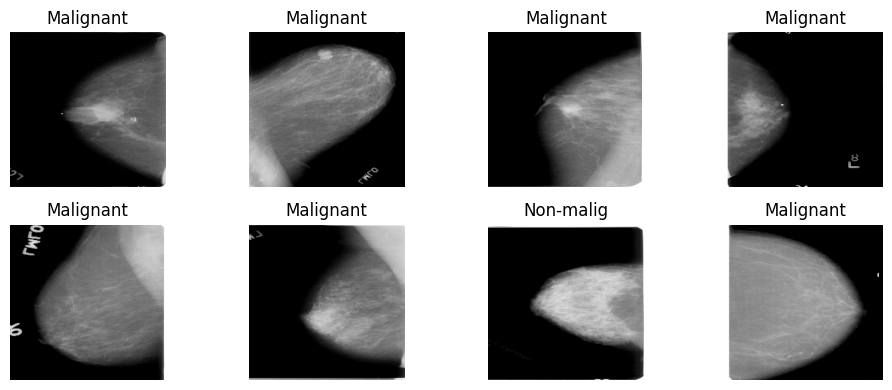

In [ ]:
# Sanity-check a batch
import matplotlib.pyplot as plt
for imgs, lbls in ds_train.take(1):
    plt.figure(figsize=(10,4))
    for i in range(8):
        plt.subplot(2,4,i+1); plt.imshow(imgs[i].numpy())
        plt.title('Malignant' if lbls[i]==1 else 'Non-malig'); plt.axis('off')
    plt.tight_layout(); plt.show()

## 4. Baseline small CNN (beat naive AUC = 0.5)

In [ ]:
def make_baseline():
    m = tf.keras.Sequential([
        tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        tf.keras.layers.Conv2D(16, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

baseline = make_baseline()
es = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                      patience=15, restore_best_weights=True)

hist_base = baseline.fit(ds_train, validation_data=ds_val,
                         epochs=150, class_weight=class_weight,
                         callbacks=[es], verbose=1)
stop_report(hist_base, es, 'Baseline')

Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 786ms/step - auc: 0.5103 - loss: 0.6932 - val_auc: 0.5370 - val_loss: 0.6935
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - auc: 0.5286 - loss: 0.6923 - val_auc: 0.5181 - val_loss: 0.6933
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - auc: 0.5162 - loss: 0.6927 - val_auc: 0.5127 - val_loss: 0.6923
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - auc: 0.5264 - loss: 0.6921 - val_auc: 0.5231 - val_loss: 0.6935
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - auc: 0.5562 - loss: 0.6890 - val_auc: 0.5276 - val_loss: 0.6916
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - auc: 0.5631 - loss: 0.6883 - val_auc: 0.5339 - val_loss: 0.6936
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - auc: 0.5638 - loss: 0.6871 - val_auc: 0.5334 - val_loss: 0.6997
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - auc: 0.5807 - loss: 0.6833 - val_auc: 0.5507 - val_loss: 0.6909
Epoch 9/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - 

In [ ]:
baseline.save('/content/drive/MyDrive/baseline_224.keras')

## 5. VGG16 transfer-learning taste (frozen base)

In [ ]:
base = tf.keras.applications.VGG16(include_top=False, weights='imagenet',
                                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False
vgg = tf.keras.Sequential([
    tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3)),
    base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
vgg.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
            loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
es_v = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                        patience=15, restore_best_weights=True)
hist_vgg = vgg.fit(ds_train, validation_data=ds_val,
                   epochs=150, class_weight=class_weight,
                   callbacks=[es_v], verbose=1)

stop_report(hist_vgg, es_v, 'VGG16')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 50s 552ms/step - auc: 0.4703 - loss: 0.8561 - val_auc: 0.5028 - val_loss: 0.6930
Epoch 2/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - auc: 0.5125 - loss: 0.7323 - val_auc: 0.5189 - val_loss: 0.6917
Epoch 3/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 195ms/step - auc: 0.5006 - loss: 0.7338 - val_auc: 0.5410 - val_loss: 0.6898
Epoch 4/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - auc: 0.5005 - loss: 0.7270 - val_auc: 0.5530 - val_loss: 0.6895
Epoch 5/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - auc: 0.5273 - loss: 0.7105 - val_auc: 0.5639 - val_loss: 0.6888
Epoch 6/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - auc: 0.5271 - loss: 0.7093 - val_auc: 0.5814 - val_loss: 0.6869
Epoch 7/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - auc: 0.5321 - loss: 0.7054 - val_auc: 0.5917 - val_loss: 0.6860
Epoch 8/150
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - auc: 0.5052 - loss: 0.7106 - val_auc: 0.6014 - val_lo

In [ ]:
vgg.save('/content/drive/MyDrive/vgg16_frozen_224.keras')

## 6. Evaluation: AUC, sensitivity, specificity, confusion matrix, ROC

In [31]:
def evaluate(model, name):
    y_prob = model.predict(ds_test, verbose=0).ravel()
    auc = roc_auc_score(y_test, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp/(tp+fn) if (tp+fn) else 0
    spec = tn/(tn+fp) if (tn+fp) else 0
    print(f'\n=== {name} ===')
    print(f'AUC-ROC:     {auc:.3f}')
    print(f'Sensitivity: {sens:.3f}')
    print(f'Specificity: {spec:.3f}')
    print(f'Confusion [tn fp / fn tp]: [{tn} {fp} / {fn} {tp}]')
    print(f'Missed cancers (FN): {fn} of {tp+fn} malignant cases')
    return auc, y_prob

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve


auc_b, prob_b = evaluate(baseline, 'Baseline CNN')
auc_v, prob_v = evaluate(vgg, 'VGG16 transfer')

plt.figure(figsize=(6,6))
for name, prob, auc in [('Baseline', prob_b, auc_b), ('VGG16', prob_v, auc_v)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--',label='Naive (0.5)')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.title('ROC on CBIS-DDSM'); plt.grid(alpha=0.3); plt.savefig('/content/drive/MyDrive/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'baseline' is not defined

**Side-by-side Confusion Matrices**

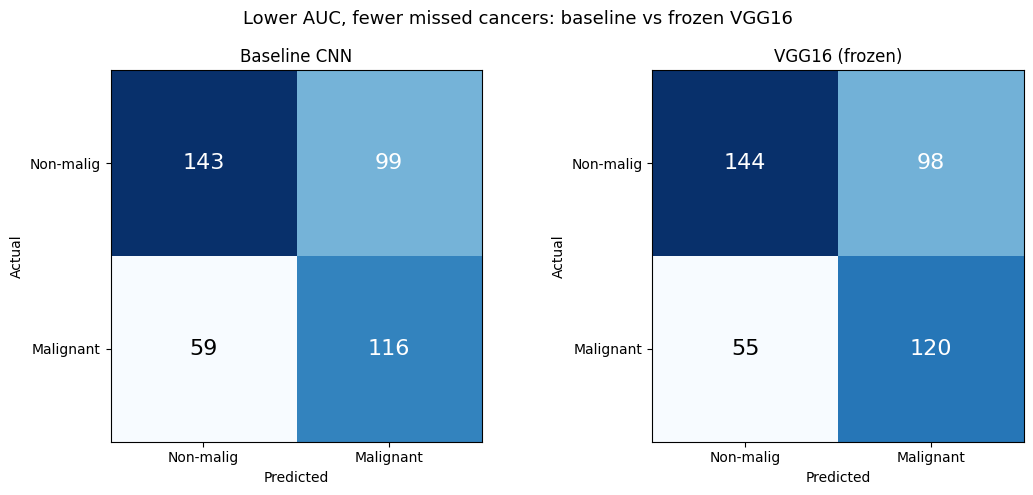

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import itertools

def plot_cm(ax, cm, title):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Non-malig','Malignant'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Non-malig','Malignant'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    for i,j in itertools.product(range(2), range(2)):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=16,
                color='white' if cm[i,j] > cm.max()/2 else 'black')

prob_b = baseline.predict(ds_test, verbose=0).ravel()
prob_v = vgg.predict(ds_test, verbose=0).ravel()
yt = y_test[:len(prob_b)]
cm_b = confusion_matrix(yt, (prob_b>=0.5).astype(int))
cm_v = confusion_matrix(yt, (prob_v>=0.5).astype(int))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,5))
plot_cm(ax1, cm_b, 'Baseline CNN')
plot_cm(ax2, cm_v, 'VGG16 (frozen)')
plt.suptitle('Lower AUC, fewer missed cancers: baseline vs frozen VGG16', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Example Predictions on real mammograms**

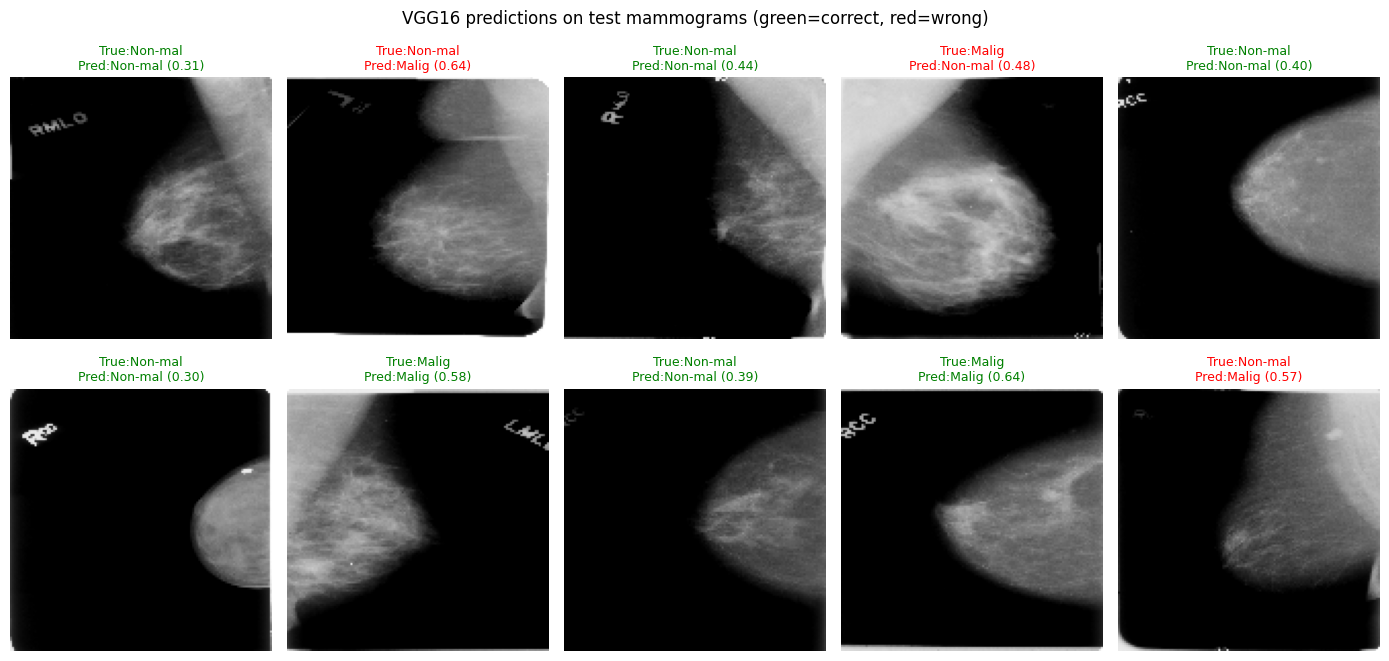

In [ ]:
# Show a grid of test images with predicted vs true labels
batch_imgs, batch_lbls = next(iter(ds_test))
preds = vgg.predict(batch_imgs, verbose=0).ravel()

plt.figure(figsize=(14, 7))
for i in range(min(10, len(batch_imgs))):
    plt.subplot(2, 5, i+1)
    plt.imshow(batch_imgs[i].numpy())
    true = 'Malig' if batch_lbls[i]==1 else 'Non-mal'
    pred = 'Malig' if preds[i]>=0.5 else 'Non-mal'
    correct = (batch_lbls[i]==1) == (preds[i]>=0.5)
    plt.title(f'True:{true}\nPred:{pred} ({preds[i]:.2f})',
              color='green' if correct else 'red', fontsize=9)
    plt.axis('off')
plt.suptitle('VGG16 predictions on test mammograms (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/example_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

**Training History, showing learning curves**

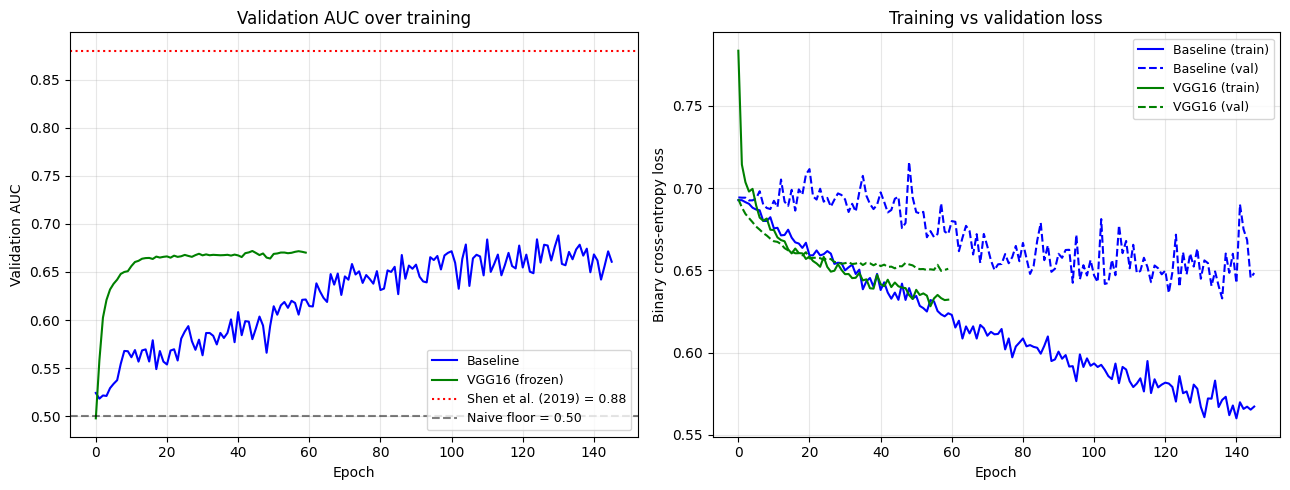

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: validation AUC ---
ax1.plot(hist_base.history['val_auc'], 'b-', lw=1.5, label='Baseline')
ax1.plot(hist_vgg.history['val_auc'],  'g-', lw=1.5, label='VGG16 (frozen)')
ax1.axhline(0.88, color='r', ls=':',  label='Shen et al. (2019) = 0.88')
ax1.axhline(0.50, color='k', ls='--', alpha=0.5, label='Naive floor = 0.50')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation AUC')
ax1.set_title('Validation AUC over training')
ax1.legend(loc='lower right', fontsize=9); ax1.grid(alpha=0.3)

# --- Right: train vs validation loss (solid = train, dashed = validation) ---
ax2.plot(hist_base.history['loss'],     'b-',  lw=1.5, label='Baseline (train)')
ax2.plot(hist_base.history['val_loss'], 'b--', lw=1.5, label='Baseline (val)')
ax2.plot(hist_vgg.history['loss'],      'g-',  lw=1.5, label='VGG16 (train)')
ax2.plot(hist_vgg.history['val_loss'],  'g--', lw=1.5, label='VGG16 (val)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Binary cross-entropy loss')
ax2.set_title('Training vs validation loss')
ax2.legend(loc='upper right', fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

**Protoype Summary**

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

BENCHMARK = 0.88  # Shen et al. (2019), CBIS-DDSM single model

def summary(prob, name):
    pred = (prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, pred).ravel()
    auc = roc_auc_score(yt, prob)
    gap = auc - BENCHMARK
    print(f"{name:18} | AUC {auc:.3f} | "
          f"Sens {tp/(tp+fn):.3f} | Spec {tn/(tn+fp):.3f} | "
          f"Missed cancers (FN): {fn:3d} | vs benchmark: {gap:+.3f}")

print("=" * 92)
print(f"{'Model':18} | {'AUC':9} | {'Sensitivity':11} | {'Specificity':11} | Missed | Gap to 0.88")
print("-" * 92)
summary(prob_b, "Baseline CNN")
summary(prob_v, "VGG16 (frozen)")
print("-" * 92)
print(f"{'Benchmark':18} | AUC 0.880 | Shen et al. (2019), CBIS-DDSM single model")
print("=" * 92)

Model              | AUC       | Sensitivity | Specificity | Missed | Gap to 0.88
--------------------------------------------------------------------------------------------
Baseline CNN       | AUC 0.717 | Sens 0.663 | Spec 0.591 | Missed cancers (FN):  59 | vs benchmark: -0.163
VGG16 (frozen)     | AUC 0.656 | Sens 0.686 | Spec 0.595 | Missed cancers (FN):  55 | vs benchmark: -0.224
--------------------------------------------------------------------------------------------
Benchmark          | AUC 0.880 | Shen et al. (2019), CBIS-DDSM single model


## 7. Fine tuning VGG16 (128x128)

The frozen experiment showed VGG16 hitting a ceiling at around epoch 15 and
then staying flat for the remaining 45 epochs. Because only the classifier
head was trainable, the model had extracted everything it could from features
that were learned on ImageNet photographs, and no amount of extra training
could move it further.

This section unfreezes the top convolutional block so those features can
adapt to greyscale mammograms. This completes stage 5 of Chollet's workflow
and tests the claim by Tajbakhsh et al. (2016) that fine tuning, rather than
feature freezing, is what makes transfer learning effective in medical imaging.

Resolution is held constant at 128x128 so that any change can be attributed
to fine tuning alone. Resolution is varied separately in section 6.

In [ ]:
!ls -lh /content/drive/MyDrive/*.keras

-rw------- 1 root root 371K Aug  8 05:54 /content/drive/MyDrive/baseline_128.keras
-rw------- 1 root root  57M Aug  8 05:54 /content/drive/MyDrive/vgg16_frozen_128.keras


In [ ]:
# Load a fresh copy of the frozen model so the original `vgg` stays intact
vgg_ft = tf.keras.models.load_model('/content/drive/MyDrive/vgg16_frozen_224.keras')
base_ft = vgg_ft.get_layer('vgg16')

# Unfreeze block5 only; earlier blocks hold generic edge and texture
# detectors that transfer well and are left alone
base_ft.trainable = True
for layer in base_ft.layers:
    layer.trainable = layer.name.startswith('block5')

# CRITICAL: must recompile for the trainable changes to take effect.
# Learning rate is 1e-5, ten times smaller than the frozen phase, so the
# pretrained weights are nudged rather than overwritten.
vgg_ft.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss='binary_crossentropy',
               metrics=[tf.keras.metrics.AUC(name='auc')])

trainable = sum(tf.keras.backend.count_params(w) for w in vgg_ft.trainable_weights)
frozen    = sum(tf.keras.backend.count_params(w) for w in vgg_ft.non_trainable_weights)
print(f'Trainable params: {trainable:,}')
print(f'Frozen params:    {frozen:,}')

Trainable params: 7,112,321
Frozen params:    7,635,264


Unfreezing block5 raises the trainable parameter count from roughly 33,000
to just over 7 million. The first four blocks stay frozen because early
convolutional layers learn generic edge and texture detectors that transfer
across image domains, while the later blocks encode object level concepts
specific to ImageNet categories.

The learning rate is the most important setting here. At the 1e-4 used for
the frozen phase, the gradients flowing back from the classifier head would
be large enough to destroy the pretrained features before they had a chance
to adapt.

In [ ]:
es_ft = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                         patience=15, restore_best_weights=True)

hist_ft = vgg_ft.fit(ds_train, validation_data=ds_val,
                     epochs=250, class_weight=class_weight,
                     callbacks=[es_ft], verbose=1)

stop_report(hist_ft, es_ft, 'VGG16 fine-tuned 224')
vgg_ft.save('/content/drive/MyDrive/vgg16_finetuned_224.keras')

Epoch 1/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - auc: 0.6998 - loss: 0.6275 - val_auc: 0.6763 - val_loss: 0.6509
Epoch 2/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 247ms/step - auc: 0.7174 - loss: 0.6170 - val_auc: 0.6746 - val_loss: 0.6515
Epoch 3/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 260ms/step - auc: 0.7237 - loss: 0.6112 - val_auc: 0.6949 - val_loss: 0.6407
Epoch 4/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - auc: 0.7415 - loss: 0.5947 - val_auc: 0.7021 - val_loss: 0.6433
Epoch 5/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step - auc: 0.7605 - loss: 0.5800 - val_auc: 0.7002 - val_loss: 0.6318
Epoch 6/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 246ms/step - auc: 0.7607 - loss: 0.5775 - val_auc: 0.7054 - val_loss: 0.6330
Epoch 7/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - auc: 0.7788 - loss: 0.5631 - val_auc: 0.7058 - val_loss: 0.6271
Epoch 8/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 249ms/step - auc: 0.7874 - loss: 0.5579 - val_auc: 0.7040 - val_loss: 0.6257
Epoch 9/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s

NameError: name 'stop_report' is not defined

In [ ]:
def stop_report(hist, es, name):
    m = hist.model
    ran  = len(hist.history['val_auc'])
    best = max(hist.history['val_auc'])
    best_ep = hist.history['val_auc'].index(best) + 1
    if es.stopped_epoch:
        print(f"{name}: STOPPED EARLY at epoch {ran} (patience {es.patience} exhausted)")
    else:
        print(f"{name}: ran all {ran} epochs, still improving, raise the ceiling")
    print(f"{name}: best val AUC {best:.4f} at epoch {best_ep}, weights restored there")
    print(f"{name}: trained model = {m.name}, {m.count_params():,} params")

In [ ]:
stop_report(hist_ft, es_ft, 'VGG16 fine-tuned 224')

VGG16 fine-tuned 224: STOPPED EARLY at epoch 56 (patience 15 exhausted)
VGG16 fine-tuned 224: best val AUC 0.7700 at epoch 41, weights restored there
VGG16 fine-tuned 224: trained model = sequential_1, 14,747,585 params


## 8. Final evaluation on the sealed test set (224x224)

All three models are evaluated on the 417-image test partition, which was held
out at the patient level and used only once, after all training and model
selection had been completed on the validation partition.

In [ ]:
baseline = tf.keras.models.load_model('/content/drive/MyDrive/baseline_224.keras')
vgg      = tf.keras.models.load_model('/content/drive/MyDrive/vgg16_frozen_224.keras')

auc_b,  prob_b  = evaluate(baseline, 'Baseline CNN (224)')
auc_v,  prob_v  = evaluate(vgg,      'VGG16 frozen (224)')
auc_ft, prob_ft = evaluate(vgg_ft,   'VGG16 fine-tuned (224)')

import numpy as np
for name, arr in [('b', prob_b), ('v', prob_v), ('ft', prob_ft)]:
    np.save(f'/content/drive/MyDrive/prob_{name}_224.npy', arr)


=== Baseline CNN (224) ===
AUC-ROC:     0.759
Sensitivity: 0.703
Specificity: 0.649
Confusion [tn fp / fn tp]: [157 85 / 52 123]
Missed cancers (FN): 52 of 175 malignant cases

=== VGG16 frozen (224) ===
AUC-ROC:     0.678
Sensitivity: 0.691
Specificity: 0.612
Confusion [tn fp / fn tp]: [148 94 / 54 121]
Missed cancers (FN): 54 of 175 malignant cases

=== VGG16 fine-tuned (224) ===
AUC-ROC:     0.746
Sensitivity: 0.514
Specificity: 0.822
Confusion [tn fp / fn tp]: [199 43 / 85 90]
Missed cancers (FN): 85 of 175 malignant cases


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score

TARGET_SENS = 0.85   # screening operating point

def at_threshold(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec, fn, fp

def threshold_for_sensitivity(y_true, prob, target):
    """Lowest threshold (highest specificity) that still reaches target sensitivity."""
    best = (0.0, 0.0, 0.0, len(y_true), 0)
    for thr in np.linspace(0.01, 0.99, 197):
        sens, spec, fn, fp = at_threshold(y_true, prob, thr)
        if sens >= target and spec > best[2]:
            best = (thr, sens, spec, fn, fp)
    return best

models = [('Baseline CNN', prob_b), ('VGG16 frozen', prob_v), ('VGG16 fine-tuned', prob_ft)]

print('=' * 86)
print(f'DEFAULT THRESHOLD 0.5   (test set: {len(y_test)} images, {int(y_test.sum())} malignant)')
print('=' * 86)
print(f"{'Model':20} | {'AUC':>5} | {'Thr':>5} | {'Sens':>5} | {'Spec':>5} | {'Missed':>6} | {'FalseAlarm':>10}")
print('-' * 86)
for name, prob in models:
    sens, spec, fn, fp = at_threshold(y_test, prob, 0.5)
    auc = roc_auc_score(y_test, prob)
    print(f'{name:20} | {auc:5.3f} | {0.50:5.2f} | {sens:5.3f} | {spec:5.3f} | {fn:6d} | {fp:10d}')

print()
print('=' * 86)
print(f'MATCHED OPERATING POINT: threshold tuned so every model reaches sensitivity >= {TARGET_SENS}')
print('=' * 86)
print(f"{'Model':20} | {'AUC':>5} | {'Thr':>5} | {'Sens':>5} | {'Spec':>5} | {'Missed':>6} | {'FalseAlarm':>10}")
print('-' * 86)
for name, prob in models:
    thr, sens, spec, fn, fp = threshold_for_sensitivity(y_test, prob, TARGET_SENS)
    auc = roc_auc_score(y_test, prob)
    print(f'{name:20} | {auc:5.3f} | {thr:5.2f} | {sens:5.3f} | {spec:5.3f} | {fn:6d} | {fp:10d}')
print('=' * 86)
print('At matched sensitivity, higher specificity = fewer unnecessary recalls = better model.')

DEFAULT THRESHOLD 0.5   (test set: 417 images, 175 malignant)
Model                |   AUC |   Thr |  Sens |  Spec | Missed | FalseAlarm
--------------------------------------------------------------------------------------
Baseline CNN         | 0.759 |  0.50 | 0.703 | 0.649 |     52 |         85
VGG16 frozen         | 0.678 |  0.50 | 0.691 | 0.612 |     54 |         94
VGG16 fine-tuned     | 0.746 |  0.50 | 0.514 | 0.822 |     85 |         43

MATCHED OPERATING POINT: threshold tuned so every model reaches sensitivity >= 0.85
Model                |   AUC |   Thr |  Sens |  Spec | Missed | FalseAlarm
--------------------------------------------------------------------------------------
Baseline CNN         | 0.759 |  0.47 | 0.857 | 0.517 |     25 |        117
VGG16 frozen         | 0.678 |  0.42 | 0.857 | 0.401 |     25 |        145
VGG16 fine-tuned     | 0.746 |  0.14 | 0.857 | 0.434 |     25 |        137
At matched sensitivity, higher specificity = fewer unnecessary recalls = better

## Results summary

### Test set (417 images, 175 malignant, 242 non-malignant)

| Model | Res | AUC | Sens | Spec | Missed | False alarms |
|---|---|---|---|---|---|---|
| Baseline CNN | 128 | 0.717 | 0.663 | 0.591 | 59 | 99 |
| Baseline CNN | 224 | 0.759 | 0.703 | 0.649 | 52 | 85 |
| VGG16 frozen | 128 | 0.656 | 0.686 | 0.595 | 55 | 98 |
| VGG16 frozen | 224 | 0.678 | 0.691 | 0.612 | 54 | 94 |
| VGG16 fine-tuned | 128 | 0.716 | 0.869 | 0.409 | 23 | 143 |
| VGG16 fine-tuned | 224 | 0.746 | 0.514 | 0.822 | 85 | 43 |

All at default threshold 0.5.

### Matched sensitivity 0.857 (224px models)

| Model | Threshold | Spec | Missed | False alarms |
|---|---|---|---|---|
| Baseline CNN | 0.47 | 0.517 | 25 | 117 |
| VGG16 fine-tuned | 0.14 | 0.434 | 25 | 137 |
| VGG16 frozen | 0.42 | 0.401 | 25 | 145 |

### Validation AUC
- Baseline 128: 0.668 mean over 4 runs, range 0.649 to 0.688
- Baseline 224: 0.7058
- VGG16 frozen 128: 0.676 mean over 2 runs
- VGG16 frozen 224: 0.6649 (ran all 150 epochs, not converged)
- VGG16 fine-tuned 128: 0.7185
- VGG16 fine-tuned 224: 0.7700 (best of project)

Noise floor: 0.039 across four identical baseline runs.
Benchmark: Shen et al. (2019), AUC 0.88 on CBIS-DDSM.

In [16]:
!ls -lh /content/drive/MyDrive/*.npy /content/drive/MyDrive/*.keras

-rw------- 1 root root 371K Aug  8 05:54 /content/drive/MyDrive/baseline_128.keras
-rw------- 1 root root 371K Aug 15 06:32 /content/drive/MyDrive/baseline_224.keras
-rw------- 1 root root 1.8K Aug  8 06:46 /content/drive/MyDrive/prob_b_128.npy
-rw------- 1 root root 1.8K Aug 15 12:08 /content/drive/MyDrive/prob_b_224.npy
-rw------- 1 root root 1.8K Aug  8 06:46 /content/drive/MyDrive/prob_ft_128.npy
-rw------- 1 root root 1.8K Aug 15 12:08 /content/drive/MyDrive/prob_ft_224.npy
-rw------- 1 root root 1.8K Aug  8 06:46 /content/drive/MyDrive/prob_v_128.npy
-rw------- 1 root root 1.8K Aug 15 12:08 /content/drive/MyDrive/prob_v_224.npy
-rw------- 1 root root 111M Aug  8 06:27 /content/drive/MyDrive/vgg16_finetuned_128.keras
-rw------- 1 root root 111M Aug 15 12:00 /content/drive/MyDrive/vgg16_finetuned_224.keras
-rw------- 1 root root  57M Aug  8 05:54 /content/drive/MyDrive/vgg16_frozen_128.keras
-rw------- 1 root root  57M Aug 15 07:06 /content/drive/MyDrive/vgg16_frozen_224.keras


In [17]:
import numpy as np
prob_b  = np.load('/content/drive/MyDrive/prob_b_224.npy')
prob_v  = np.load('/content/drive/MyDrive/prob_v_224.npy')
prob_ft = np.load('/content/drive/MyDrive/prob_ft_224.npy')
print(len(prob_b), len(prob_v), len(prob_ft), len(y_test))

417 417 417 417


## 9. Ensemble analysis

Shen et al. (2019) improved their single-model AUC of 0.88 to 0.91 by averaging
four models. This section tests whether the same technique helps here. Because
the models sit on different probability scales, predictions are combined by rank
averaging rather than by averaging raw probabilities.

In [18]:
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score

def rank_avg(*probs):
    return np.mean([rankdata(p) / len(p) for p in probs], axis=0)

combos = {
    'baseline + fine-tuned': rank_avg(prob_b, prob_ft),
    'baseline + frozen':     rank_avg(prob_b, prob_v),
    'fine-tuned + frozen':   rank_avg(prob_ft, prob_v),
    'all three':             rank_avg(prob_b, prob_v, prob_ft),
}

print(f"{'model':28} {'test AUC':>9}")
print('-' * 38)
for n, p in [('Baseline alone', prob_b), ('Frozen alone', prob_v), ('Fine-tuned alone', prob_ft)]:
    print(f'{n:28} {roc_auc_score(y_test, p):9.3f}')
print('-' * 38)
for n, p in combos.items():
    print(f'{n:28} {roc_auc_score(y_test, p):9.3f}')

model                         test AUC
--------------------------------------
Baseline alone                   0.759
Frozen alone                     0.678
Fine-tuned alone                 0.746
--------------------------------------
baseline + fine-tuned            0.783
baseline + frozen                0.746
fine-tuned + frozen              0.729
all three                        0.764


## 10. Stronger augmentation

The fine-tuned model reached a training AUC of 0.933 against a validation AUC of
0.770, a generalisation gap of 0.163. With 7.1 million trainable parameters and
only 2,035 training images, this was expected. Rather than reducing capacity,
this section attacks the gap by expanding the effective size of the training set.

The augmentations are chosen to reflect variation that genuinely occurs in
mammography: patient positioning varies slightly between acquisitions (rotation,
translation), breast size and compression vary (zoom), and exposure differs
between machines and settings (contrast). Augmentations that would produce
anatomically impossible images are avoided.

In [19]:
data_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.04),          # about +/- 14 degrees
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.20),
], name='augmentation')

ds_train_aug = (tf.data.Dataset.from_tensor_slices((p_train, y_train))
                .map(load_img, num_parallel_calls=AUTOTUNE)
                .cache()
                .shuffle(len(p_train), seed=SEED)
                .batch(BATCH)
                .map(lambda x, y: (data_augment(x, training=True), y),
                     num_parallel_calls=AUTOTUNE)
                .prefetch(AUTOTUNE))

print('ds_train_aug built. ds_val and ds_test unchanged (never augmented).')

ds_train_aug built. ds_val and ds_test unchanged (never augmented).


In [20]:
vgg_aug = tf.keras.models.load_model('/content/drive/MyDrive/vgg16_frozen_224.keras')
base_aug = vgg_aug.get_layer('vgg16')
base_aug.trainable = True
for layer in base_aug.layers:
    layer.trainable = layer.name.startswith('block5')

vgg_aug.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                loss='binary_crossentropy',
                metrics=[tf.keras.metrics.AUC(name='auc')])

trainable = sum(tf.keras.backend.count_params(w) for w in vgg_aug.trainable_weights)
print(f'Trainable: {trainable:,}')

es_aug = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                          patience=25, restore_best_weights=True)

hist_aug = vgg_aug.fit(ds_train_aug, validation_data=ds_val,
                       epochs=250, class_weight=class_weight,
                       callbacks=[es_aug], verbose=1)

stop_report(hist_aug, es_aug, 'VGG16 fine-tuned + augmentation')
vgg_aug.save('/content/drive/MyDrive/vgg16_finetuned_aug_224.keras')

Trainable: 7,112,321
Epoch 1/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - auc: 0.6558 - loss: 0.6554 - val_auc: 0.6632 - val_loss: 0.6545
Epoch 2/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 543ms/step - auc: 0.6757 - loss: 0.6428 - val_auc: 0.6621 - val_loss: 0.6550
Epoch 3/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 541ms/step - auc: 0.6802 - loss: 0.6411 - val_auc: 0.6690 - val_loss: 0.6506
Epoch 4/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 36s 538ms/step - auc: 0.6989 - loss: 0.6259 - val_auc: 0.6627 - val_loss: 0.6538
Epoch 5/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 542ms/step - auc: 0.7133 - loss: 0.6164 - val_auc: 0.6599 - val_loss: 0.6543
Epoch 6/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 654ms/step - auc: 0.7059 - loss: 0.6226 - val_auc: 0.6598 - val_loss: 0.6532
Epoch 7/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 679ms/step - auc: 0.7085 - loss: 0.6190 - val_auc: 0.6414 - val_loss: 0.6614
Epoch 8/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 570ms/step - auc: 0.7226 - loss: 0.6099 - val_auc: 0.6564 - val_loss: 0.6552
Epoch 9/250
64/64 ━━━

NameError: name 'stop_report' is not defined

In [21]:
vgg_aug.save('/content/drive/MyDrive/vgg16_finetuned_aug_224.keras')

In [24]:
print([type(t).__name__ for t in [ds_train, ds_train_aug]])

['_PrefetchDataset', '_PrefetchDataset']


In [27]:
src = tf.keras.models.load_model('/content/drive/MyDrive/vgg16_frozen_224.keras')
base_reg = src.get_layer('vgg16')

base_reg.trainable = True
for layer in base_reg.layers:
    layer.trainable = layer.name.startswith('block5')

L2 = tf.keras.regularizers.l2(1e-4)
vgg_reg = tf.keras.Sequential([
    tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3)),
    base_reg,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=L2),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=L2),
])

vgg_reg.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                loss='binary_crossentropy',
                metrics=[tf.keras.metrics.AUC(name='auc')])

print('regularisation losses:', len(vgg_reg.losses))   # must be > 0

regularisation losses: 2


In [28]:
es_reg = tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                          patience=20, restore_best_weights=True)

hist_reg = vgg_reg.fit(ds_train, validation_data=ds_val,
                       epochs=250, class_weight=class_weight,
                       callbacks=[es_reg], verbose=1)

stop_report(hist_reg, es_reg, 'VGG16 fine-tuned + L2')
vgg_reg.save('/content/drive/MyDrive/vgg16_finetuned_l2_224.keras')


Epoch 1/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 287ms/step - auc: 0.5166 - loss: 0.7155 - val_auc: 0.6129 - val_loss: 0.6970
Epoch 2/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 226ms/step - auc: 0.5667 - loss: 0.6985 - val_auc: 0.6467 - val_loss: 0.6877
Epoch 3/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 232ms/step - auc: 0.6424 - loss: 0.6768 - val_auc: 0.6549 - val_loss: 0.6723
Epoch 4/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 241ms/step - auc: 0.6643 - loss: 0.6623 - val_auc: 0.6629 - val_loss: 0.6679
Epoch 5/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 242ms/step - auc: 0.6841 - loss: 0.6518 - val_auc: 0.6652 - val_loss: 0.6665
Epoch 6/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - auc: 0.6831 - loss: 0.6513 - val_auc: 0.6725 - val_loss: 0.6810
Epoch 7/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 256ms/step - auc: 0.6828 - loss: 0.6476 - val_auc: 0.6765 - val_loss: 0.6612
Epoch 8/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - auc: 0.6981 - loss: 0.6393 - val_auc: 0.6820 - val_loss: 0.6712
Epoch 9/250
64/64 ━━━━━━━━━━━━━━━━━━━━ 1

In [32]:
vgg_reg.save('/content/drive/MyDrive/vgg16_finetuned_l2_224.keras')

auc_l2, prob_l2 = evaluate(vgg_reg, 'VGG16 fine-tuned + L2 (224)')
np.save('/content/drive/MyDrive/prob_l2_224.npy', prob_l2)

for name, p in [('baseline + fine-tuned', rank_avg(prob_b, prob_ft)),
                ('baseline + L2',         rank_avg(prob_b, prob_l2)),
                ('fine-tuned + L2',       rank_avg(prob_ft, prob_l2)),
                ('b + ft + L2',           rank_avg(prob_b, prob_ft, prob_l2))]:
    print(f'{name:24} {roc_auc_score(y_test, p):.3f}')


=== VGG16 fine-tuned + L2 (224) ===
AUC-ROC:     0.758
Sensitivity: 0.709
Specificity: 0.645
Confusion [tn fp / fn tp]: [156 86 / 51 124]
Missed cancers (FN): 51 of 175 malignant cases
baseline + fine-tuned    0.783
baseline + L2            0.789
fine-tuned + L2          0.755
b + ft + L2              0.783


## Final results (224x224, sealed test set: 417 images, 175 malignant)

### Single models
| Model | Test AUC | Sens | Spec | Missed |
|---|---|---|---|---|
| VGG16 frozen | 0.678 | 0.691 | 0.612 | 54 |
| VGG16 fine-tuned | 0.746 | 0.514 | 0.822 | 85 |
| VGG16 fine-tuned + L2 | 0.758 | 0.709 | 0.645 | 51 |
| Baseline CNN | 0.759 | 0.703 | 0.649 | 52 |

### Ensembles (rank averaging)
| Combination | Test AUC |
|---|---|
| Baseline + L2 | **0.789** |
| Baseline + fine-tuned | 0.783 |
| Baseline + fine-tuned + L2 | 0.783 |
| Fine-tuned + L2 | 0.755 |

Ensemble gain +0.030 over best single model, the same magnitude Shen et al.
(2019) obtained from four-model averaging (0.88 to 0.91).

### Regularisation comparison (validation, at best epoch)
| Run | Train | Val | Gap |
|---|---|---|---|
| Fine-tuned, flips only | 0.9330 | 0.7700 | 0.163 |
| Fine-tuned + augmentation | 0.8993 | 0.7331 | 0.166 |
| Fine-tuned + L2 | 0.8864 | 0.7481 | 0.138 |

L2 narrowed the generalisation gap; augmentation did not.

Noise floor: 0.039 (four identical baseline runs at 128px).
Benchmark: Shen et al. (2019), AUC 0.88 on CBIS-DDSM.

## 11. Figures for the report

All figures used in the report are regenerated here from the saved 224x224
predictions, so that every figure demonstrably comes from the same set of
experiments as the reported numbers. Earlier plots in this notebook were
produced during development at 128x128 and are retained only as a record of
the process.

loaded: {'Baseline CNN': 417, 'VGG16 frozen': 417, 'VGG16 fine-tuned': 417, 'VGG16 fine-tuned + L2': 417, 'Ensemble (baseline + L2)': 417} | y_test: 417


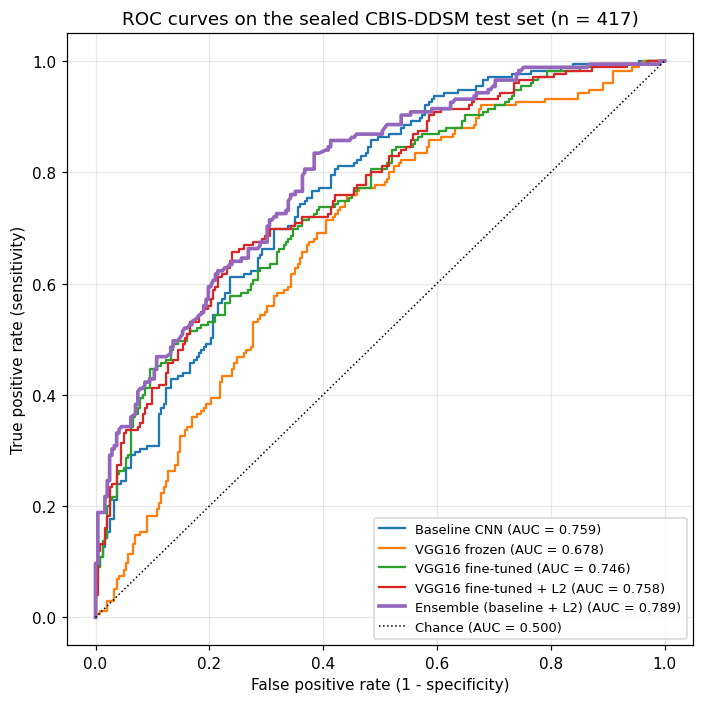

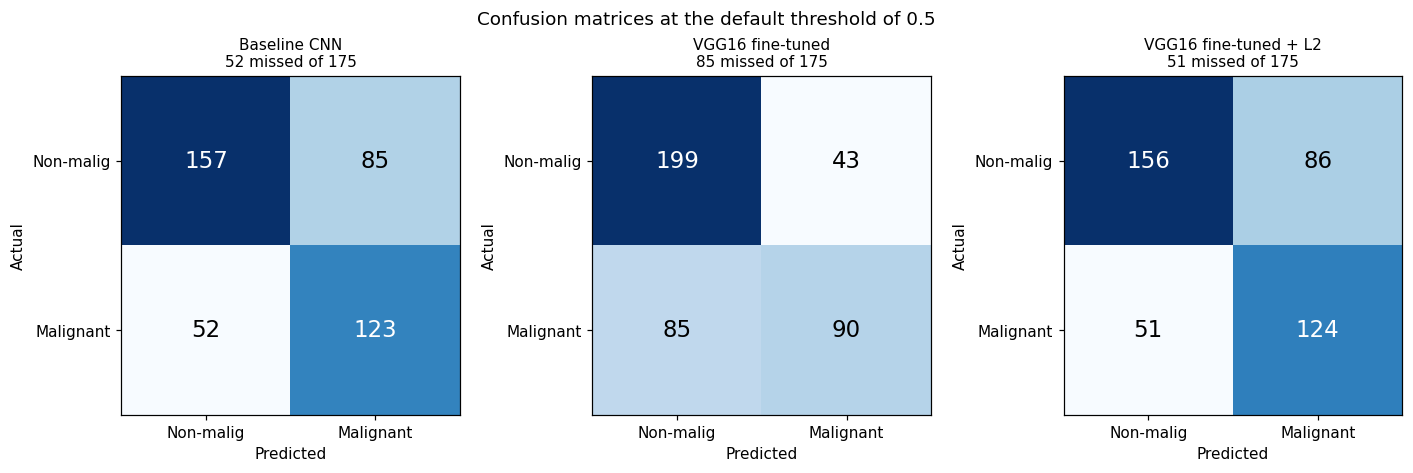

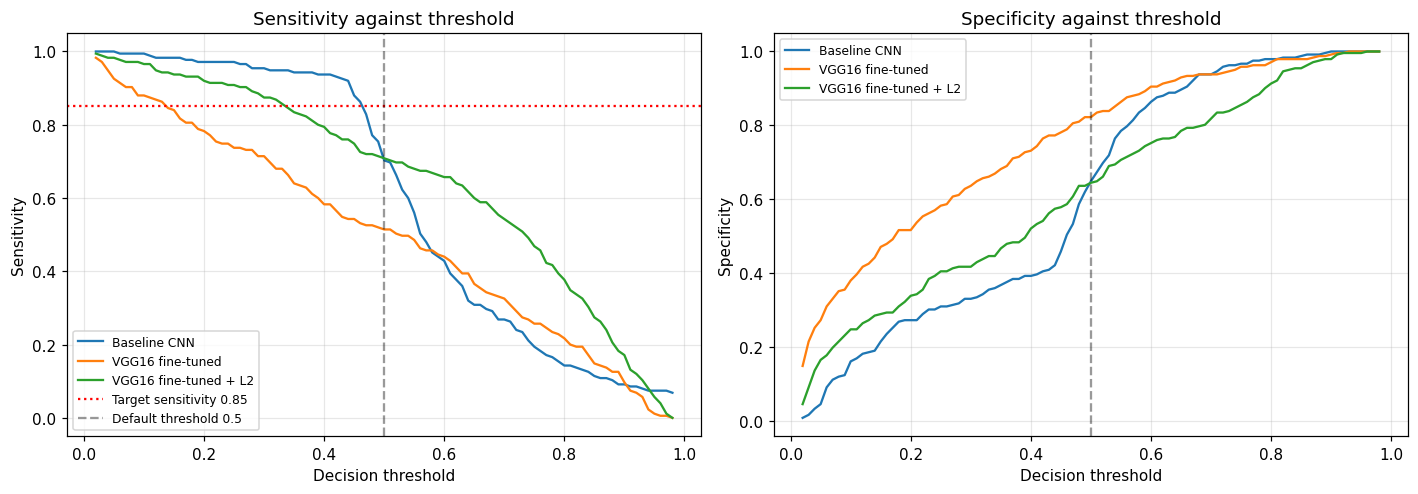

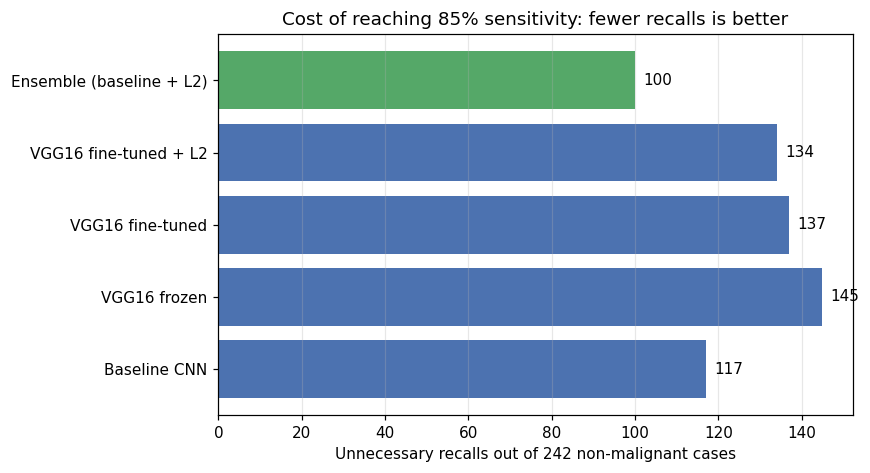


Saved to /content/drive/MyDrive/figures
['fig_roc_all.png', 'fig_confusion.png', 'fig_threshold.png', 'fig_matched_sensitivity.png']


In [34]:
import numpy as np, matplotlib.pyplot as plt, itertools, os
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

FIGDIR = '/content/drive/MyDrive/figures'
os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams.update({'font.size': 10, 'figure.dpi': 110})

P = {k: np.load(f'/content/drive/MyDrive/prob_{v}_224.npy')
     for k, v in {'Baseline CNN': 'b', 'VGG16 frozen': 'v',
                  'VGG16 fine-tuned': 'ft', 'VGG16 fine-tuned + L2': 'l2'}.items()}

def rank_avg(*probs):
    return np.mean([rankdata(p) / len(p) for p in probs], axis=0)

P['Ensemble (baseline + L2)'] = rank_avg(P['Baseline CNN'], P['VGG16 fine-tuned + L2'])
print('loaded:', {k: len(v) for k, v in P.items()}, '| y_test:', len(y_test))

# --- Figure 1: ROC curves ---
plt.figure(figsize=(6.5, 6.5))
for name, prob in P.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    lw = 2.4 if 'Ensemble' in name else 1.5
    plt.plot(fpr, tpr, lw=lw, label=f'{name} (AUC = {roc_auc_score(y_test, prob):.3f})')
plt.plot([0, 1], [0, 1], 'k:', lw=1, label='Chance (AUC = 0.500)')
plt.xlabel('False positive rate (1 - specificity)')
plt.ylabel('True positive rate (sensitivity)')
plt.title('ROC curves on the sealed CBIS-DDSM test set (n = 417)')
plt.legend(loc='lower right', fontsize=8.5); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{FIGDIR}/fig_roc_all.png', bbox_inches='tight'); plt.show()

# --- Figure 2: confusion matrices at 0.5 ---
show = ['Baseline CNN', 'VGG16 fine-tuned', 'VGG16 fine-tuned + L2']
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, name in zip(axes, show):
    cm = confusion_matrix(y_test, (P[name] >= 0.5).astype(int))
    ax.imshow(cm, cmap='Blues')
    lo, hi = cm.min(), cm.max()
    for i, j in itertools.product(range(2), range(2)):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=15,
                color='white' if cm[i, j] > (lo + hi) / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Non-malig', 'Malignant'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Non-malig', 'Malignant'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{name}\n{cm[1,0]} missed of 175', fontsize=10)
plt.suptitle('Confusion matrices at the default threshold of 0.5', fontsize=12)
plt.tight_layout(); plt.savefig(f'{FIGDIR}/fig_confusion.png', bbox_inches='tight'); plt.show()

# --- Figure 3: sensitivity and specificity against threshold ---
thr_grid = np.linspace(0.02, 0.98, 97)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for name in show:
    sens = [((P[name] >= t) & (y_test == 1)).sum() / (y_test == 1).sum() for t in thr_grid]
    spec = [((P[name] <  t) & (y_test == 0)).sum() / (y_test == 0).sum() for t in thr_grid]
    axes[0].plot(thr_grid, sens, label=name)
    axes[1].plot(thr_grid, spec, label=name)
axes[0].axhline(0.85, color='r', ls=':', label='Target sensitivity 0.85')
axes[0].axvline(0.5, color='k', ls='--', alpha=0.4, label='Default threshold 0.5')
axes[1].axvline(0.5, color='k', ls='--', alpha=0.4)
axes[0].set_xlabel('Decision threshold'); axes[0].set_ylabel('Sensitivity')
axes[1].set_xlabel('Decision threshold'); axes[1].set_ylabel('Specificity')
axes[0].set_title('Sensitivity against threshold'); axes[1].set_title('Specificity against threshold')
for a in axes: a.grid(alpha=0.3); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIGDIR}/fig_threshold.png', bbox_inches='tight'); plt.show()

# --- Figure 4: false alarms at matched sensitivity ---
def spec_at_sens(prob, target=0.85):
    best = (0, 0, len(y_test))
    for t in np.linspace(0.01, 0.99, 197):
        tn, fp, fn, tp = confusion_matrix(y_test, (prob >= t).astype(int)).ravel()
        if tp / (tp + fn) >= target and tn / (tn + fp) > best[1]:
            best = (t, tn / (tn + fp), fp)
    return best

names = list(P.keys())
fps = [spec_at_sens(P[n])[2] for n in names]
plt.figure(figsize=(8, 4.4))
bars = plt.barh(names, fps, color=['#4C72B0'] * (len(names) - 1) + ['#55A868'])
for b, v in zip(bars, fps):
    plt.text(v + 2, b.get_y() + b.get_height() / 2, str(v), va='center', fontsize=10)
plt.xlabel('Unnecessary recalls out of 242 non-malignant cases')
plt.title('Cost of reaching 85% sensitivity: fewer recalls is better')
plt.grid(axis='x', alpha=0.3); plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_matched_sensitivity.png', bbox_inches='tight'); plt.show()

print('\nSaved to', FIGDIR); print(os.listdir(FIGDIR))

In [35]:
import json
hists = {}
for name, h in [('baseline_224', 'hist_base'), ('frozen_224', 'hist_vgg'),
                ('finetuned_224', 'hist_ft'), ('augmented_224', 'hist_aug'),
                ('l2_224', 'hist_reg')]:
    if h in globals():
        hists[name] = {k: [float(x) for x in v] for k, v in globals()[h].history.items()}
        print(f'saved {name}: {len(hists[name]["val_auc"])} epochs')
    else:
        print(f'MISSING {h}')

with open('/content/drive/MyDrive/histories_224.json', 'w') as f:
    json.dump(hists, f)

MISSING hist_base
MISSING hist_vgg
MISSING hist_ft
saved augmented_224: 90 epochs
saved l2_224: 86 epochs


In [38]:
!ls -lh /content/drive/MyDrive/*.ipynb
!ls -lh /content/drive/MyDrive/'Colab Notebooks'/*.ipynb

ls: cannot access '/content/drive/MyDrive/*.ipynb': No such file or directory
-rw------- 1 root root 280K Jan  7  2026 '/content/drive/MyDrive/Colab Notebooks/CM3005.ipynb'
-rw------- 1 root root 738K Jun 29 06:23 '/content/drive/MyDrive/Colab Notebooks/CM3070_Prototype_CBIS_DDSM_Kaggle.ipynb'
-rw------- 1 root root  90K Nov 11  2025 '/content/drive/MyDrive/Colab Notebooks/Copy of CM3010 DADT Topic 4 : MySQL NodeJS Demonstraton.ipynb'
-rw------- 1 root root 136K Nov 11  2025 '/content/drive/MyDrive/Colab Notebooks/Copy of CM3010 DADT Topic 4 : MySQL Python Demonstraton.ipynb'
-rw------- 1 root root 3.4M Apr 16  2025 '/content/drive/MyDrive/Colab Notebooks/Copy of DAC_Thoughtfull_III (1).ipynb'
-rw------- 1 root root 3.4M Apr 16  2025 '/content/drive/MyDrive/Colab Notebooks/Copy of DAC_Thoughtfull_III.ipynb'
-rw------- 1 root root 3.4M Apr 16  2025 '/content/drive/MyDrive/Colab Notebooks/DAC_Thoughtfull_III.ipynb'
-rw------- 1 root root 810K Dec 18  2024 '/content/drive/MyDrive/Colab No